<a href="https://colab.research.google.com/github/HariPrasad017/ml-leakage-pipeline-Hari_Prasad_S_S/blob/main/house_price_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1 — What I’m Doing

So here, my goal is pretty straightforward — I want to predict house prices based on things like:

- Area (square feet)
- Number of bedrooms
- Age of the house

Basically, I’m building a multiple linear regression model and then checking how good it is.

# Task 1 — Create Dataset & Train Model

In [1]:
import pandas as pd
import numpy as np

# Creating the synthetic dataset
np.random.seed(42)

data = {
    'area_sqft': np.random.randint(500, 3000, 60),
    'num_bedrooms': np.random.randint(1, 5, 60),
    'age_years': np.random.randint(0, 30, 60)
}

df = pd.DataFrame(data)

# Creating the target variable (price)
df['price_lakhs'] = (
    df['area_sqft'] * 0.05 +
    df['num_bedrooms'] * 10 -
    df['age_years'] * 0.5 +
    np.random.normal(0, 5, 60)  # noise
)

df.head()

,area_sqft,num_bedrooms,age_years,price_lakhs
0,1360,2,1,86.973714
1,1794,2,0,104.923268
2,1630,2,15,91.926177
3,1595,4,22,101.756296
4,2138,2,22,114.179597


# Train Model

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Features and target
X = df[['area_sqft', 'num_bedrooms', 'age_years']]
y = df['price_lakhs']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Print intercept and coefficients
print("Intercept:", model.intercept_)
print("Coefficients:", list(zip(X.columns, model.coef_)))

Intercept: -1.892219112831583
Coefficients: [('area_sqft', np.float64(0.05076011681397917)), ('num_bedrooms', np.float64(9.749370826092173)), ('age_years', np.float64(-0.43668089030596136))]


# Actual vs Predicted

In [3]:
# Predictions
y_pred = model.predict(X_test)

# Compare first 5 values
comparison = pd.DataFrame({
    'Actual': y_test.values[:5],
    'Predicted': y_pred[:5]
})

comparison

,Actual,Predicted
0,86.973714,86.203601
1,152.703929,150.170899
2,171.193643,160.470350
3,124.202710,125.557829
4,76.202781,81.147749


# Task 2 — Model Evaluation

In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 4.546695245816879
RMSE: 6.040714144964896
R² Score: 0.9784090046218633


### Understanding of the Task

- MAE tells me the average error in prediction in lakhs.
- RMSE penalizes larger errors more, so it helps me understand if big mistakes exist.
- R² shows how well my model explains the data (closer to 1 means better fit).

# Task 3 — Residual Analysis

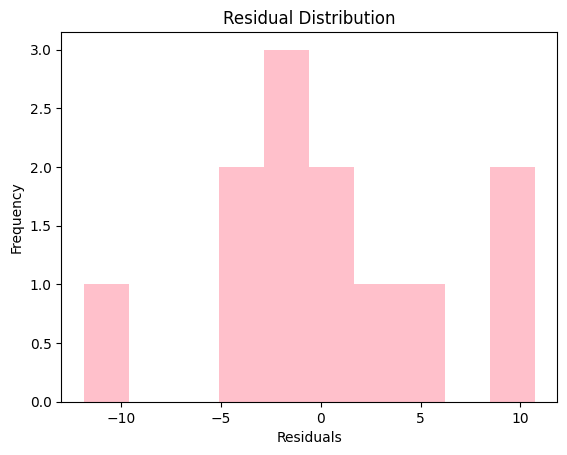

In [6]:
import matplotlib.pyplot as plt

# Residuals
residuals = y_test - y_pred

# Plot histogram
plt.hist(residuals, bins=10, color = "pink")
plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

### Explanation

- A residual is the difference between the actual value and the predicted value.

- If the histogram looks roughly centered around zero and somewhat symmetric, it means the model is not biased and is making balanced errors.

- If it is skewed or spread out, it suggests the model may not be capturing some patterns properly.